# Computer Vision
## Exercise Sheet 3: Image Center, Edges, Keypoints
### Erhardt Barth / Christoph Linse / Manuel Laufer / Kathleen Anderson
Universität zu Lübeck, Institut für Neuro- und Bioinformatik

In case of questions, contact us via email: *{erhardt.barth, c.linse, m.laufer, k.anderson} @uni-luebeck.de*

## Note: Please insert the names of all participating students:

1.
2.
3.
4.
5.


In [1]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs4250.git'
    os.chdir('cs4250')

Cloning into 'cs4250'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 97 (delta 43), reused 71 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 1.26 MiB | 9.91 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.morphology import dilation

%matplotlib inline

## Exercise 3.1
### Finding the Image Center
Camera calibration refers to the process of computing the intrinsic and extrinsic parameters of the camera. It is a necessary step in many computer vision applications such as 3D scene reconstruction and recognition. One important intrinsic parameter is the image center. Print out the images `ueb311.jpg` and `ueb312.jpg` and estimate the image centers by using a ruler.

**Hint**: Make small printouts of the images to have enough space around them.

In [3]:
def load_image_gray(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image

In [4]:
def load_image_gray_normalized(image_path):
    return load_image_gray(image_path).astype('float32')/255.

In [5]:
def gradient(image):
    v = .5
    k_y = np.zeros((3, 3))
    k_y[0, 1] = -v
    k_y[2, 1] = +v

    k_x = np.zeros((3, 3))
    k_x[1, 0] = -v
    k_x[1, 2] = +v

    image = np.copy(image).astype('float32')

    gradient_x = cv2.filter2D(image, -1, k_x)
    gradient_y = cv2.filter2D(image, -1, k_y)

    return gradient_x, gradient_y


## Exercise 3.2.1
### Edge Detection
Open the image `ueb32.jpg` in Python and show the image gradients $d_x$ and $d_y$. Compute the magnitude of gradients image and apply a threshold to retain only the edges of the object. For those edges, compute and show the gradient angle image (`np.arctan2`). How can you tell the angle of the gradient from looking only at the gradients?

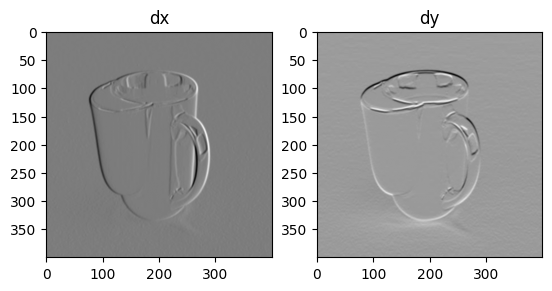

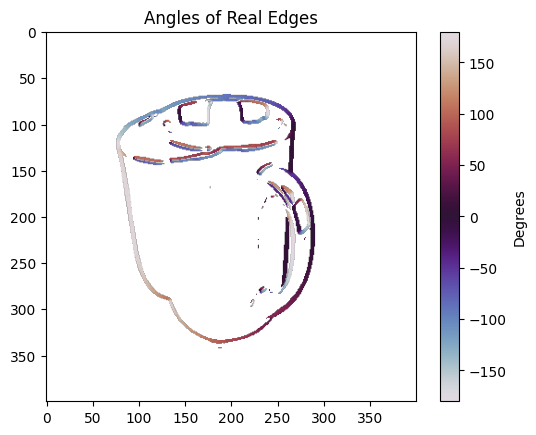

In [91]:
# load image
img = load_image_gray('/content/cs4250/data/exercise_3/ueb32.jpg')

# smooth image
img = cv2.GaussianBlur(img, (5, 5), 0)

# compute and show gradient images
dx, dy = gradient(img)

# make images comparable
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(dx, cmap='gray')
ax1.set_title('dx')
ax2.imshow(dy, cmap='gray')
ax2.set_title('dy')
plt.show()

# compute gradient magnitude
mag = np.sqrt(dx**2 + dy**2)

# compute an angle image that should be in range [-180,+180]
ang = np.arctan2(dy, dx)
ang = np.degrees(ang)

# show angles only for real edges
threshold = 10
edges = np.where(mag > threshold, ang, np.nan)

# Display final filtered angles
plt.figure()
plt.imshow(edges, cmap='twilight', vmin=-180, vmax=180)
plt.colorbar(label='Degrees')
plt.title('Angles of Real Edges')
plt.show()

## Exercise 3.2.2
### Canny Edge Detector
Open the image `ueb32.jpg` in Python and use the OpenCV Canny algorithm to find the edges in the image.
Compare the result with the magnitude of gradient image. Display both results side by side using `plt.subplots`.
Comment on how the two results differ and why.**Furthermore, comment how the angle image and the magnitude image are used in the Canny algorithm.**

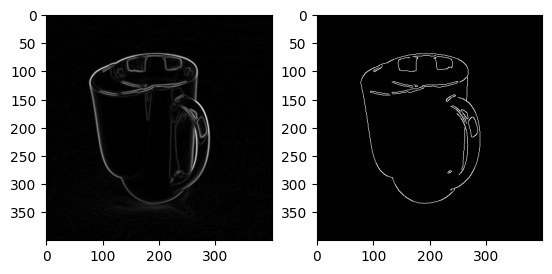

In [94]:
# load image
img1 = load_image_gray('/content/cs4250/data/exercise_3/ueb32.jpg')
img0 = np.copy(img1)
# compute magnitude of gradient image
img0 = cv2.GaussianBlur(img0, (3, 3), 0)
img1 = cv2.GaussianBlur(img1, (3, 3), 0)
dx, dy = gradient(img0)
mag = np.sqrt(dx**2 + dy**2)
# apply canny
threshold1 = 90
threshold2 = max(img1.flatten())
img1 = cv2.Canny(img1, threshold1=threshold1, threshold2=threshold2)
# compare results
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(mag, cmap='gray')
ax2.imshow(img1, cmap='gray')
plt.show()

## Exercise 3.3
### Key Point Detection
Implement the following key-point detectors:
* local maxima of $K$
* local maxima of $K$ − $\alpha$ $H^2$, with $\alpha$ as weighting parameter

The function is supposed to return images of the same size as the input, where the pixels contain $K$ or $K$ − $\alpha$ $H^2$.

$K$ and $H$ should be the invariants of the structure tensor $J$ (see script).
Evaluate the detectors above on two kinds of test images: (i) the synthetic image `ueb331.npy`, (ii) the
picture `ueb332.jpg`.

Comment your results with a focus on
1. the localization of the key points
2. the influence of the $H$ term as controlled via the parameter $\alpha$.

**Question**: Why do you filter the image with a Gaussian kernel a second time? It is **not** about noise removal!

**Hint**: Use the provided functions `find_local_max` and `plot_marks`.

In [66]:
def find_local_max(keypoints, thres=1e-6, k=3):
    kernel = np.ones((k, k))
    kernel[k//2, k//2] = 0
    local_max = keypoints > thres + dilation(keypoints, kernel)

    return local_max

In [67]:
def plot_marks(map, ax=None):
    if ax is None:
        _, ax = plt.subplots(1)
    col, row = np.nonzero(map)

    ax.plot(row, col, 'r.')

In [124]:
def key_points_structure(image, alpha, sigma=.1):
    # image parameters

    # 0. filter with Gaussian kernel with sigma
    image = cv2.GaussianBlur(image, (3, 3), sigma)
    # 1. partial derivatives
    dx, dy = gradient(image)
    # 2. product images
    j00 = dx**2
    j11 = dy**2
    j10 = dx*dy
    # 3. filter with gaussian kernel with sigma = 1
    j00 = cv2.GaussianBlur(j00, (3, 3), 1)
    j11 = cv2.GaussianBlur(j11, (3, 3), 1)
    j10 = cv2.GaussianBlur(j10, (3, 3), 1)
    # 4. compute invarians for J
    K = (j00 * j11) - (j10 ** 2)
    H = (j00 + j11)
    K_minus_H = K - (alpha * H**2)
    return K, K_minus_H


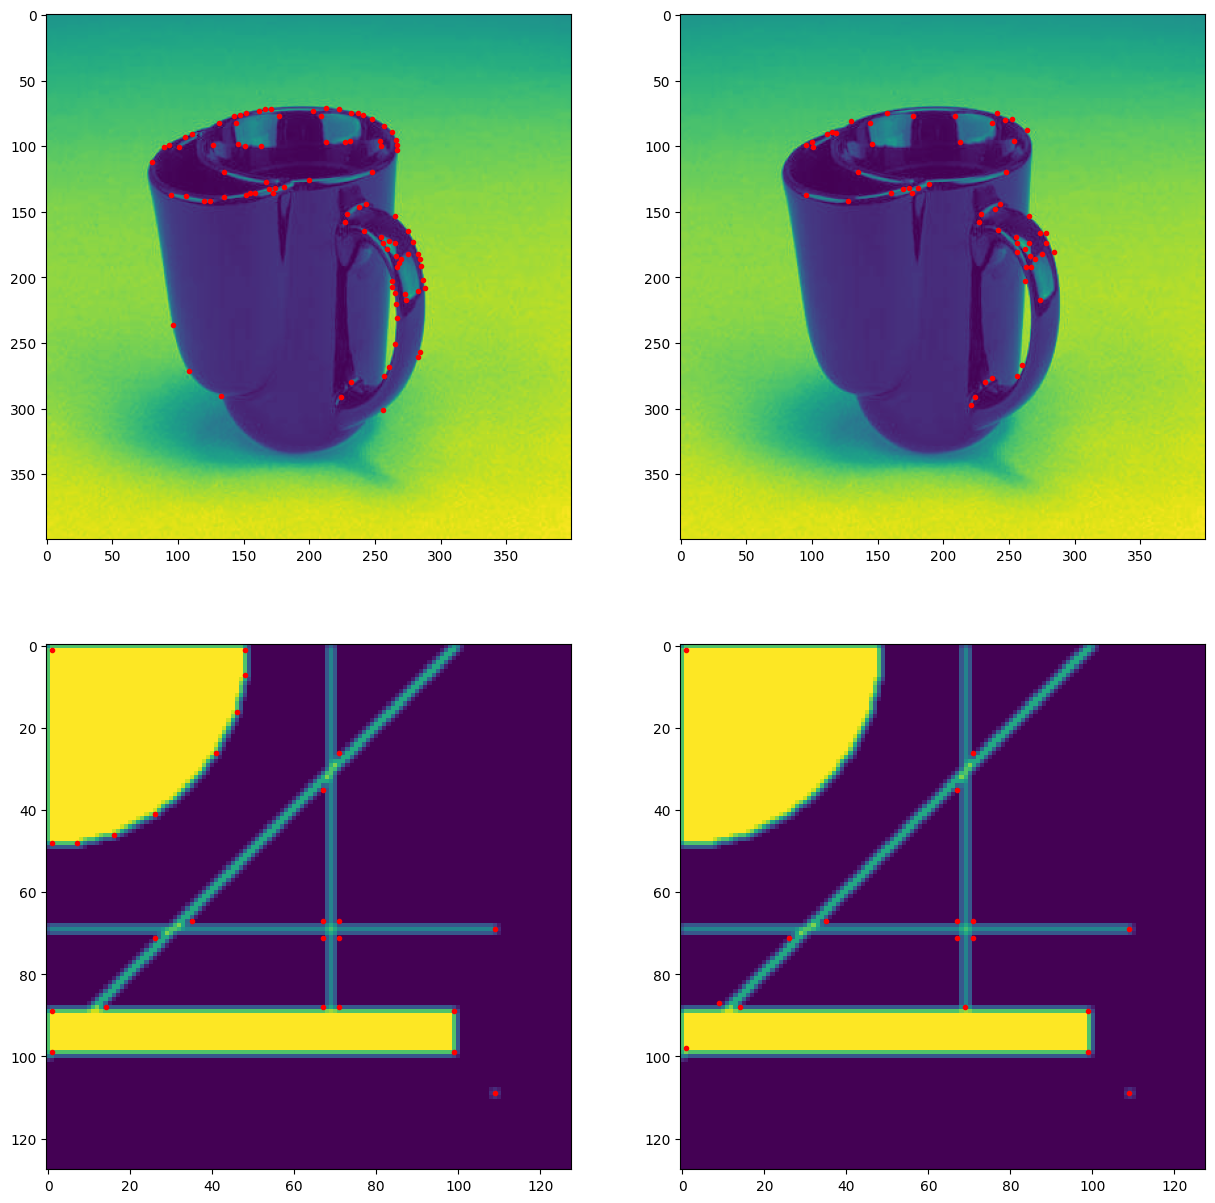

In [125]:
# define alpha, sigma, and k
alpha = 0.04
sigma = 1e-6
k = 5
# load images
img0 = np.load('/content/cs4250/data/exercise_3/ueb331.npy')
img1 = load_image_gray_normalized('/content/cs4250/data/exercise_3/ueb332.jpg')
# extract keypoints
K0, K0_minus_H = key_points_structure(img0, alpha=alpha, sigma=sigma)
K1, K1_minus_H = key_points_structure(img1, alpha=alpha, sigma=sigma)
# show found keypoints (K, K_minus_H) for both images
# example
_, ax = plt.subplots(2, 2, figsize=(15, 15))
local_max = find_local_max(K1, sigma, k)
ax[0][0].imshow(img1)
plot_marks(local_max, ax[0][0])

local_max = find_local_max(K1_minus_H, sigma, k)
ax[0][1].imshow(img1)
plot_marks(local_max, ax[0][1])

local_max = find_local_max(K0, sigma, k)
ax[1][0].imshow(img0)
plot_marks(local_max, ax[1][0])

local_max = find_local_max(K0_minus_H, sigma, k)
ax[1][1].imshow(img0)
plot_marks(local_max, ax[1][1])
